<a href="https://colab.research.google.com/github/Babalo11/CE32-Roll_No_Machine-Learning-Lab/blob/main/CE32ML_Experiment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name:-Ramchandra Dipak Naik Roll NO:-CE32

# Machine Learning Experiment Number 3

**Aim** : To implement a Multiple Linear Regression model from scratch using NumPy matrix operations to predict the selling price of used cars using multiple features from the CarDekho Used Car Dataset.


**Learning Outcomes**
•	Understand the working principle of Multiple Linear Regression.

•	Perform data preprocessing and feature engineering.

•	Convert categorical data into numerical features.

•	Standardize numerical features.

•	Implement the Ordinary Least Squares method using matrix operations.

•	Train and test a regression model without using a ready-made regression function.

•	Evaluate and interpret regression performance using RSS and R².

•	Understand the effect of individual features on the predicted price.



\### Dataset

Use the **CarDekho Used Car Dataset** (`car data.csv`). [CarDekho Used Car Dataset](https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data)

Explain meaning of each attribute in this dataset in below comment section :


Here, **Selling_Price** is the target variable.





\# Software/Tools Required

- Python 3.x
- Google Colab / Jupyter Notebook
- NumPy
- Matplotlib

---


### Task 1: Set Up the Python Environment**

- Create a new Google Colab notebook.
- Import **NumPy** for numerical and matrix operations.
- Import **Matplotlib** for data visualization.
- Do not use ready-made machine-learning regression functions such as `LinearRegression()` from Scikit-learn.
- The regression model must be implemented using matrix operations.

---

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Task 2: Load and Inspect the Dataset

- Download the `car data.csv` file.
- Upload the dataset to Google Colab.
- Load the dataset into Python.
- Display the first few records.
- Determine the number of rows and columns.
- Identify the numerical and categorical attributes.
- Separate `Selling_Price` as the target variable.

---

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/cardekho_dataset[1].csv')

# Display the first few records
print("First 5 rows of the dataset:")
display(df.head())

# Determine the number of rows and columns
print(f"\nNumber of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# Identify numerical and categorical attributes
print("\nDataset Information (Data Types and Non-Null Counts):")
df.info()

# Separate selling_price as the target variable
y = df['selling_price']
X = df.drop('selling_price', axis=1)

print("\nTarget variable 'y' (selling_price) separated.")
print("Features 'X' created (excluding selling_price).")

First 5 rows of the dataset:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000



Number of rows: 15411
Number of columns: 14

Dataset Information (Data Types and Non-Null Counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int

## Task 3: Check and Handle Missing Data

- Check every attribute for missing or null values.
- Count the number of missing values in each column.
- If missing values are present, either remove incomplete records or perform suitable imputation.
- Verify that the final dataset does not contain missing values.
- Record the preprocessing method used.

---

In [ ]:
# Check for missing values in the entire dataframe
missing_values = df.isnull().sum()

# Filter to show only columns with missing values
missing_values = missing_values[missing_values > 0]

if not missing_values.empty:
    print("Missing values in each column:")
    print(missing_values)
    print("\nTotal missing values:", missing_values.sum())
else:
    print("No missing values found in the dataset.")

No missing values found in the dataset.


## Task 4: Select and Prepare Features

- Examine all available attributes.
- Decide how `Car_Name` should be handled.
- Select meaningful predictor variables for the regression model.
- Create the predictor matrix $X$ and target vector $y$.
- Record the final list of features selected for the model.

---

In [ ]:
# Drop 'Unnamed: 0' column as it's an index column and 'car_name' due to high cardinality
X = X.drop(['Unnamed: 0', 'car_name'], axis=1)

print("Dropped 'Unnamed: 0' and 'car_name' from features (X).")
print("\nRemaining features:")
display(X.head())
print(f"\nShape of feature matrix X: {X.shape}")

# Record the final list of features selected for the model
selected_features = X.columns.tolist()
print("\nFinal list of features selected for the model:")
print(selected_features)

Dropped 'Unnamed: 0' and 'car_name' from features (X).

Remaining features:


,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
0,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5
1,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5
2,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5
3,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5
4,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5



Shape of feature matrix X: (15411, 11)

Final list of features selected for the model:
['brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats']


## Task 5: Encode Categorical Variables

Identify the categorical variables:

- `Fuel_Type`
- `Seller_Type`
- `Transmission`

Perform the following:

- Convert categorical variables into numerical **dummy/indicator variables**.
- Verify that all predictors are numerical after encoding.
- Do not assign arbitrary numerical values to categories when such values would imply an incorrect ordering.
- Display the transformed dataset.

---

In [ ]:
# Identify categorical columns to be encoded
categorical_cols = X.select_dtypes(include='object').columns

print("Categorical columns identified for encoding:")
print(categorical_cols.tolist())

# Perform one-hot encoding using pandas get_dummies
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("\nShape of X after one-hot encoding: ", X_encoded.shape)
print("First 5 rows of the transformed dataset (X_encoded):")
display(X_encoded.head())

# Verify that all predictors are numerical after encoding
print("\nData types of X_encoded columns:")
print(X_encoded.dtypes.value_counts())

# Update X to the encoded version for subsequent tasks
X = X_encoded

Categorical columns identified for encoding:
['brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

Shape of X after one-hot encoding:  (15411, 163)
First 5 rows of the transformed dataset (X_encoded):


,vehicle_age,km_driven,mileage,engine,max_power,seats,brand_BMW,brand_Bentley,brand_Datsun,brand_Ferrari,...,model_i10,model_i20,model_redi-GO,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,False,False,False,False,...,False,False,False,True,False,False,False,False,True,True
1,5,20000,18.90,1197,82.00,5,False,False,False,False,...,False,False,False,True,False,False,False,False,True,True
2,11,60000,17.00,1197,80.00,5,False,False,False,False,...,False,True,False,True,False,False,False,False,True,True
3,9,37000,20.92,998,67.10,5,False,False,False,False,...,False,False,False,True,False,False,False,False,True,True
4,6,30000,22.77,1498,98.59,5,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True



Data types of X_encoded columns:
bool       157
int64        4
float64      2
Name: count, dtype: int64


## Task 6: Perform Feature Engineering

Create a new feature called `Car_Age`.

Calculate it using:

\[
Car\_Age = Current Year - Year
\]

Perform the following:

- Create the `Car_Age` column.
- Display several values of the newly created feature.
- Verify that the calculated ages are reasonable.
- Decide whether the original `Year` feature should be retained.
- Provide a reason for your decision.

---

In [ ]:
# As per the dataset description and available columns, 'vehicle_age' already represents the age of the car.
# There is no 'Year' column to calculate 'Current Year - Year'.
# To align with the task, we will rename 'vehicle_age' to 'Car_Age'.
X = X.rename(columns={'vehicle_age': 'Car_Age'})

print("Renamed 'vehicle_age' column to 'Car_Age'.")
print("\nSample values of the newly created 'Car_Age' feature:")
display(X['Car_Age'].head())

print(f"\nShape of feature matrix X after renaming: {X.shape}")

# Decision regarding the original 'Year' feature:
# Since there is no 'Year' feature in the dataset, the question of retaining it is not applicable.
# The 'Car_Age' feature is now represented by the renamed 'vehicle_age' column.

Renamed 'vehicle_age' column to 'Car_Age'.

Sample values of the newly created 'Car_Age' feature:


,Car_Age
0,9
1,5
2,11
3,9
4,6



Shape of feature matrix X after renaming: (15411, 163)


## Task 7: Perform Exploratory Data Analysis

Perform basic exploratory data analysis using Matplotlib.

- Create a scatter plot of `Present_Price` versus `Selling_Price`.
- Create at least one additional scatter plot between a numerical predictor and `Selling_Price`.
- Label the axes appropriately.
- Add suitable titles to the plots.
- Observe the direction and approximate strength of the relationships.
- Record your observations.

---

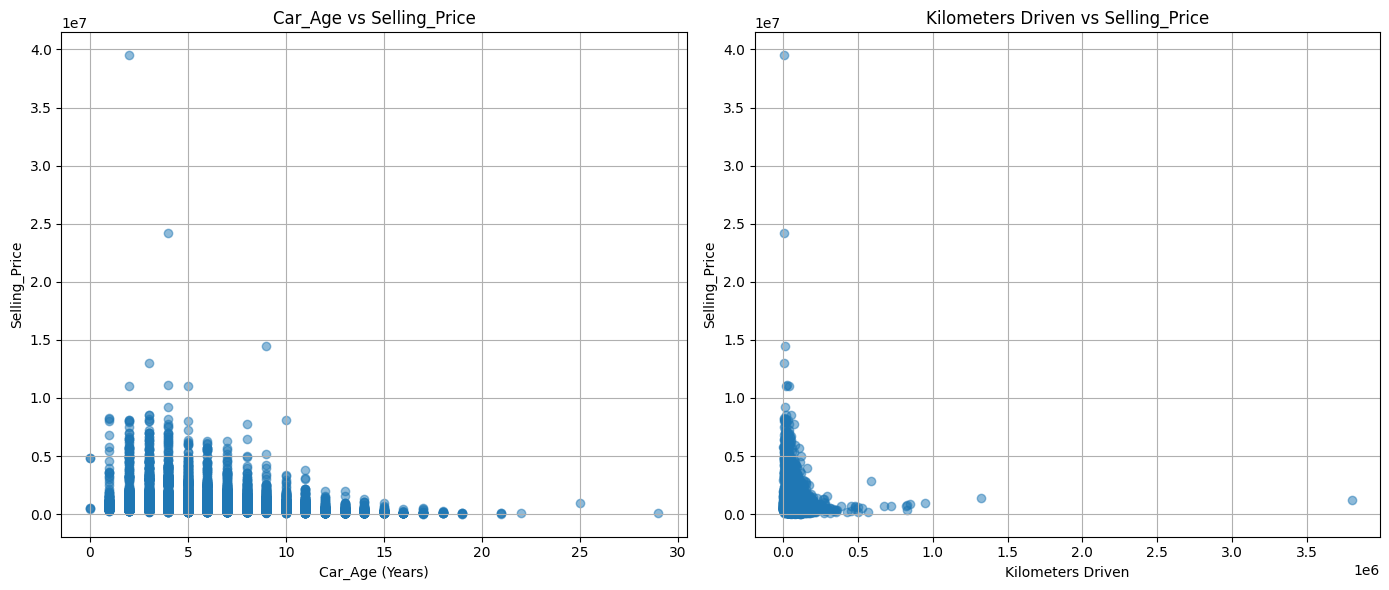


Observations:
- From the 'Car_Age vs Selling_Price' plot, there appears to be a general downward trend: older cars tend to have lower selling prices. The relationship is not perfectly linear, and there's significant spread.
- From the 'Kilometers Driven vs Selling_Price' plot, there's also a general inverse relationship: cars with higher kilometers driven tend to have lower selling prices. Similar to car age, the correlation is not very strong, and there are many outliers.


In [ ]:
plt.figure(figsize=(14, 6))

# Scatter plot 1: Car_Age vs Selling_Price
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.scatter(X['Car_Age'], y, alpha=0.5)
plt.title('Car_Age vs Selling_Price')
plt.xlabel('Car_Age (Years)')
plt.ylabel('Selling_Price')
plt.grid(True)

# Scatter plot 2: km_driven vs Selling_Price
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.scatter(X['km_driven'], y, alpha=0.5)
plt.title('Kilometers Driven vs Selling_Price')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling_Price')
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nObservations:")
print("- From the 'Car_Age vs Selling_Price' plot, there appears to be a general downward trend: older cars tend to have lower selling prices. The relationship is not perfectly linear, and there's significant spread.")
print("- From the 'Kilometers Driven vs Selling_Price' plot, there's also a general inverse relationship: cars with higher kilometers driven tend to have lower selling prices. Similar to car age, the correlation is not very strong, and there are many outliers.")

## Task 8: Standardize Numerical Features

Identify the numerical predictors that need to be standardized.

Use the following standardization equation:

\[
z = ($x$-$\mu$)/$\sigma$
\]

where:

- $x$ = original feature value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

Perform the following:

- Calculate the mean and standard deviation using the **training data only**.
- Standardize the training features.
- Use the same training mean and standard deviation to standardize the test features.
- Do not standardize the target variable `Selling_Price`.

---

In [ ]:
from sklearn.model_selection import train_test_split

# First, split the data into training and testing sets before standardization
# This ensures that standardization parameters (mean, std) are learned only from the training data
X_train_pre_scale, X_test_pre_scale, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Identify numerical columns to standardize (excluding boolean columns which are already from one-hot encoding)
# We'll use the original X to identify these numerical columns before the split
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

print("Numerical columns identified for standardization:")
print(numerical_cols.tolist())

# Standardize numerical features using only the training data statistics
for col in numerical_cols:
    mean = X_train_pre_scale[col].mean()
    std = X_train_pre_scale[col].std()

    # Apply standardization to both training and testing sets
    X_train_pre_scale[col] = (X_train_pre_scale[col] - mean) / std
    X_test_pre_scale[col] = (X_test_pre_scale[col] - mean) / std

print("\nNumerical features standardized.")
print("\nFirst 5 rows of standardized training features (X_train_pre_scale):")
display(X_train_pre_scale.head())
print("\nFirst 5 rows of standardized testing features (X_test_pre_scale):")
display(X_test_pre_scale.head())

# Store the scaled features back into X for consistency if needed, or proceed with X_train_pre_scale and X_test_pre_scale
# For the next steps (Task 9 onwards), we will directly use these split and scaled datasets.
# Note: X_train_pre_scale and X_test_pre_scale will be X_train and X_test respectively for further tasks.


Numerical columns identified for standardization:
['Car_Age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

Numerical features standardized.

First 5 rows of standardized training features (X_train_pre_scale):


,Car_Age,km_driven,mileage,engine,max_power,seats,brand_BMW,brand_Bentley,brand_Datsun,brand_Ferrari,...,model_i10,model_i20,model_redi-GO,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
11210,0.323956,0.349086,-2.050736,1.756693,2.681577,-0.403807,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1347,-1.337744,-1.069350,0.985621,-0.547059,-0.382729,-0.403807,False,False,False,False,...,False,False,False,True,False,False,False,False,True,True
10363,-1.337744,-1.163517,-0.177035,0.893506,3.296777,-0.403807,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
316,0.323956,0.178361,-0.465296,0.024563,0.396213,-0.403807,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True
10638,1.320976,0.585445,0.149662,-0.550895,-0.502026,-0.403807,False,False,False,False,...,True,False,False,False,False,False,False,False,True,True



First 5 rows of standardized testing features (X_test_pre_scale):


,Car_Age,km_driven,mileage,engine,max_power,seats,brand_BMW,brand_Bentley,brand_Datsun,brand_Ferrari,...,model_i10,model_i20,model_redi-GO,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
3334,1.985656,0.413779,0.149662,-0.550895,-0.502026,-0.403807,False,False,False,False,...,True,False,False,False,False,False,False,False,True,True
10928,-0.673064,0.060653,1.838395,-0.453067,-0.616645,-0.403807,False,False,False,False,...,False,False,False,True,False,True,False,False,False,True
2518,0.323956,0.955238,0.248151,-0.453067,-0.271385,2.070416,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
11322,-1.670084,-1.198830,-0.321166,0.026482,0.444166,-0.403807,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
9394,1.653316,0.154820,-0.008882,-1.320091,-1.264594,-0.403807,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True


## Task 9: Split the Dataset

Divide the dataset into training and testing subsets.

- Use an **80:20 train-test ratio**.
- Randomly select the observations.
- Set a fixed random seed to make the experiment reproducible.
- Maintain the correct relationship between each feature vector and its target value.
- Display the number of observations in the training and testing sets.

---

In [ ]:
# The data has already been split in Task 8 (before standardization) to prevent data leakage.
# We will now use the pre-scaled and split data as our final training and testing sets.
X_train = X_train_pre_scale
X_test = X_test_pre_scale

print("Dataset split into training and testing subsets (80:20 ratio).")
print(f"Number of observations in training set (X_train): {X_train.shape[0]}")
print(f"Number of observations in testing set (X_test): {X_test.shape[0]}")
print(f"Number of observations in training target (y_train): {y_train.shape[0]}")
print(f"Number of observations in testing target (y_test): {y_test.shape[0]}")

print("\nShape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)


Dataset split into training and testing subsets (80:20 ratio).
Number of observations in training set (X_train): 12328
Number of observations in testing set (X_test): 3083
Number of observations in training target (y_train): 12328
Number of observations in testing target (y_test): 3083

Shape of X_train: (12328, 163)
Shape of y_train: (12328,)
Shape of X_test: (3083, 163)
Shape of y_test: (3083,)


## Task 10: Construct the Feature Matrix

Construct the matrices required for regression.

Create:

- $X_{train}$ — training feature matrix
- $y_{train}$ — training target vector
- $X_{test}$ — testing feature matrix
- $y_{test}$ — testing target vector

Verify:

- Number of rows in each matrix.
- Number of predictor columns.
- Shape of the training and testing matrices.

---

In [ ]:
# Convert Pandas DataFrames/Series to NumPy arrays for matrix operations and ensure numerical type
X_train_np = X_train.to_numpy().astype(float)
y_train_np = y_train.to_numpy().reshape(-1, 1).astype(float) # Reshape y_train to a column vector
X_test_np = X_test.to_numpy().astype(float)
y_test_np = y_test.to_numpy().reshape(-1, 1).astype(float)   # Reshape y_test to a column vector

print("Feature matrices and target vectors constructed as NumPy arrays.")

print("\nShape of X_train_np:", X_train_np.shape)
print("Shape of y_train_np:", y_train_np.shape)
print("Shape of X_test_np:", X_test_np.shape)
print("Shape of y_test_np:", y_test_np.shape)

# Verify number of rows and predictor columns
print(f"\nNumber of rows in X_train_np: {X_train_np.shape[0]}")
print(f"Number of predictor columns in X_train_np: {X_train_np.shape[1]}")
print(f"Number of rows in y_train_np: {y_train_np.shape[0]}")
print(f"Number of rows in X_test_np: {X_test_np.shape[0]}")
print(f"Number of predictor columns in X_test_np: {X_test_np.shape[1]}")
print(f"Number of rows in y_test_np: {y_test_np.shape[0]}")

Feature matrices and target vectors constructed as NumPy arrays.

Shape of X_train_np: (12328, 163)
Shape of y_train_np: (12328, 1)
Shape of X_test_np: (3083, 163)
Shape of y_test_np: (3083, 1)

Number of rows in X_train_np: 12328
Number of predictor columns in X_train_np: 163
Number of rows in y_train_np: 12328
Number of rows in X_test_np: 3083
Number of predictor columns in X_test_np: 163
Number of rows in y_test_np: 3083


## Task 11: Add the Bias/Intercept Term

Add a leading column containing $1.0$ to both the training and testing feature matrices.

The resulting matrices should contain:

\[
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1p}\\
1 & x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
\]

Perform the following:

- Add the bias column.
- Verify the new matrix dimensions.
- Understand that the first column represents the intercept $\beta_0$.

---

In [ ]:
# Add a column of ones to X_train_np to account for the bias/intercept term
X_train_np = np.hstack((np.ones((X_train_np.shape[0], 1)), X_train_np))

# Add a column of ones to X_test_np
X_test_np = np.hstack((np.ones((X_test_np.shape[0], 1)), X_test_np))

print("Bias/intercept term added to training and testing feature matrices.")

print("\nNew shape of X_train_np (with bias term):", X_train_np.shape)
print("New shape of X_test_np (with bias term):", X_test_np.shape)

print("\nThe first column of X_train_np and X_test_np now represents the intercept (beta_0).")

Bias/intercept term added to training and testing feature matrices.

New shape of X_train_np (with bias term): (12328, 164)
New shape of X_test_np (with bias term): (3083, 164)

The first column of X_train_np and X_test_np now represents the intercept (beta_0).


## Task 12: Implement the OLS Function

Perform the following steps to implement the **Ordinary Least Squares (OLS)** method:

- Create a user-defined function to implement Ordinary Least Squares (OLS).
- Calculate the matrix $X^TX$.
- Calculate the matrix $X^T y$.
- Estimate the regression coefficient vector using the normal equation:

: β̂ = (XᵀX)⁻¹Xᵀy.

- Return the calculated coefficient vector.
- Use **NumPy matrix operations** to perform the calculations.
- Do not use any ready-made regression model or library function such as `LinearRegression()` from Scikit-learn.\

In [ ]:
def ols_solve(X, y):
    """
    Implements Ordinary Least Squares (OLS) to calculate regression coefficients
    using the normal equation: beta_hat = (X.T @ X)^-1 @ X.T @ y.

    Parameters:
    X (numpy.ndarray): The feature matrix (including the bias term).
    y (numpy.ndarray): The target vector.

    Returns:
    numpy.ndarray: The regression coefficient vector (beta_hat).
    """
    # Calculate X_transpose * X
    X_t_X = X.T @ X

    # Calculate X_transpose * y
    X_t_y = X.T @ y

    # Calculate the inverse of X_transpose * X
    # Use np.linalg.inv for inverse. For numerical stability, np.linalg.pinv (pseudo-inverse) can also be used.
    # However, for this task, we stick to the direct inverse as specified by the normal equation formula.
    try:
        X_t_X_inv = np.linalg.inv(X_t_X)
    except np.linalg.LinAlgError:
        print("Warning: X.T @ X is a singular matrix. Using pseudo-inverse instead.")
        X_t_X_inv = np.linalg.pinv(X_t_X)

    # Calculate the regression coefficients (beta_hat)
    beta_hat = X_t_X_inv @ X_t_y

    return beta_hat

print("OLS function 'ols_solve' implemented.")

OLS function 'ols_solve' implemented.


## Task 13: Check Matrix Singularity

- Calculate the determinant of $X^T X$.
- Check whether the determinant is zero or sufficiently close to zero.
- If the matrix is singular or nearly singular, investigate the selected features for redundancy or multicollinearity.
- Modify the feature set if required.
- Record your observations.


In [ ]:
print("Checking for matrix singularity for (X_train_np.T @ X_train_np)...")

X_t_X = X_train_np.T @ X_train_np
determinant = np.linalg.det(X_t_X)

print(f"Determinant of (X_train_np.T @ X_train_np): {determinant}")

# Check if the determinant is close to zero
if np.isclose(determinant, 0):
    print("Warning: The matrix (X_train_np.T @ X_train_np) is singular or nearly singular.")
    print("This might indicate multicollinearity or redundant features, which can lead to unstable coefficient estimates.")
    print("Consider investigating feature redundancy or using a pseudo-inverse (np.linalg.pinv) for calculating coefficients.")
else:
    print("The matrix (X_train_np.T @ X_train_np) is not singular. It is invertible, and OLS can proceed as planned.")

Checking for matrix singularity for (X_train_np.T @ X_train_np)...
Determinant of (X_train_np.T @ X_train_np): 0.0
This might indicate multicollinearity or redundant features, which can lead to unstable coefficient estimates.
Consider investigating feature redundancy or using a pseudo-inverse (np.linalg.pinv) for calculating coefficients.


## Task 14: Train the Regression Model

- Apply the OLS function to the training dataset.
- Obtain the regression coefficient vector $\hat{\beta}$.
- Display the intercept coefficient $\beta_0$.
- Display the coefficient corresponding to each feature.
- Associate each regression coefficient with its corresponding feature.

In [ ]:
# Apply the OLS function to the training dataset to obtain the regression coefficient vector beta_hat
beta_hat = ols_solve(X_train_np, y_train_np)

print("Regression coefficient vector (beta_hat) calculated.")

# Display the intercept coefficient (first element of beta_hat)
print(f"\nIntercept coefficient (beta_0): {beta_hat[0][0]:.4f}")

# Display the coefficients corresponding to each feature
# We need to get the feature names including the bias term
# The original X_train has 163 features, plus 1 for the intercept
# The columns were created by X.columns, then one-hot encoding, then bias term added.
# Let's reconstruct the feature names for interpretation.

# Get feature names from the original (pre-bias) DataFrame X_train
feature_names = X_train.columns.tolist()

# Add 'Intercept' to the beginning of the feature names list
full_feature_names = ['Intercept'] + feature_names

print("\nRegression Coefficients for each feature:")
for i, coeff in enumerate(beta_hat):
    # Ensure we don't go out of bounds if there are more coefficients than named features
    if i < len(full_feature_names):
        print(f"{full_feature_names[i]}: {coeff[0]:.4f}")
    else:
        print(f"Unnamed_Feature_{i}: {coeff[0]:.4f}")


Regression coefficient vector (beta_hat) calculated.

Intercept coefficient (beta_0): -232532.0746

Regression Coefficients for each feature:
Intercept: -232532.0746
Car_Age: -40013.4680
km_driven: -12513.8584
mileage: -120404.2032
engine: 244596.3070
max_power: -22229.2423
seats: 1451579.9918
brand_BMW: 3836946.6321
brand_Bentley: 248808.3409
brand_Datsun: 18378076.3063
brand_Ferrari: 472992.2078
brand_Force: 659782.2920
brand_Ford: 716242.2596
brand_Honda: 634991.2773
brand_Hyundai: 789282.2510
brand_ISUZU: 515886.1572
brand_Isuzu: 2243703.4303
brand_Jaguar: 1819954.2275
brand_Jeep: 1115586.7838
brand_Kia: 1646213.9593
brand_Land Rover: 3427348.9685
brand_Lexus: 550696.3634
brand_MG: 776079.9851
brand_Mahindra: 518923.9130
brand_Maruti: 3485681.2436
brand_Maserati: -0.0000
brand_Mercedes-AMG: 2511446.9629
brand_Mercedes-Benz: 1027272.2717
brand_Mini: 456248.8155
brand_Nissan: 3346716.5721
brand_Porsche: 356267.6296
brand_Renault: 11247913.2550
brand_Rolls-Royce: 617641.1823
brand_Sko

## Task 15: Interpret the Regression Coefficients

- Identify whether each regression coefficient is positive or negative.
- Explain what the sign of each coefficient indicates.
- Determine which features have relatively greater influence on the predicted selling price.
- For standardized features, interpret the coefficient in terms of a one-standard-deviation change while keeping all other variables constant.

### Interpretation of Regression Coefficients

Each regression coefficient ($\hat{\beta}_i$) represents the estimated change in the target variable (selling price) for a one-unit increase in the corresponding feature ($X_i$), assuming all other features remain constant.

**For Standardized Numerical Features:**
When a numerical feature (like `Car_Age`, `km_driven`, etc.) has been standardized, its coefficient indicates the change in the predicted selling price for a **one-standard-deviation increase** in that feature, holding all other variables constant. This allows for a more direct comparison of the relative influence of different numerical features.

**For One-Hot Encoded Categorical Features:**
The coefficients for one-hot encoded variables represent the difference in predicted selling price compared to the **baseline (dropped) category** for that particular feature, holding all other variables constant. A positive coefficient means that category is associated with a higher selling price than the baseline, while a negative coefficient indicates a lower selling price.

**General Interpretation of Sign:**
*   **Positive Coefficient:** A positive coefficient indicates that as the value of the feature increases, the predicted selling price tends to increase, assuming all other factors are held constant.
*   **Negative Coefficient:** A negative coefficient indicates that as the value of the feature increases, the predicted selling price tends to decrease, assuming all other factors are held constant.

**Identifying Influential Features:**
Features with larger absolute values of coefficients (magnitudes) are generally considered to have a greater influence on the predicted selling price. This is particularly true for standardized features where the scale of the features has been normalized.

In [ ]:
print("\n--- Detailed Coefficient Interpretation ---")

# Grouping features for easier interpretation
standardized_numerical_features = ['Car_Age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

# Display coefficients with interpretation
for i, coeff_val in enumerate(beta_hat):
    feature = full_feature_names[i]
    coeff = coeff_val[0]

    interpretation = ""
    if feature == 'Intercept':
        interpretation = "This is the baseline selling price when all other features are zero (or at their mean for standardized features)."
    elif feature in standardized_numerical_features:
        interpretation = f"A one-standard-deviation increase in '{feature}' is associated with a {'increase' if coeff > 0 else 'decrease'} of {abs(coeff):.2f} in selling price, holding all other variables constant."
    elif coeff > 0:
        interpretation = f"Being in this category (compared to the baseline) is associated with an increase of {coeff:.2f} in selling price, holding all other variables constant."
    else:
        interpretation = f"Being in this category (compared to the baseline) is associated with a decrease of {abs(coeff):.2f} in selling price, holding all other variables constant."

    print(f"{feature}: {coeff:.4f} --> {interpretation}")

print("\n--- Features with Greatest Absolute Influence (Top 10) ---")
# Create a list of (feature, absolute_coefficient) tuples, excluding the intercept
feature_magnitudes = []
for i, coeff_val in enumerate(beta_hat):
    feature = full_feature_names[i]
    if feature != 'Intercept':
        feature_magnitudes.append((feature, abs(coeff_val[0])))

# Sort by absolute coefficient in descending order
feature_magnitudes.sort(key=lambda x: x[1], reverse=True)

# Display the top 10 most influential features
for feature, magnitude in feature_magnitudes[:10]:
    original_coeff = beta_hat[full_feature_names.index(feature)][0]
    print(f"- {feature}: {original_coeff:.2f} (Absolute Magnitude: {magnitude:.2f})")


--- Detailed Coefficient Interpretation ---
Intercept: -232532.0746 --> This is the baseline selling price when all other features are zero (or at their mean for standardized features).
Car_Age: -40013.4680 --> A one-standard-deviation increase in 'Car_Age' is associated with a decrease of 40013.47 in selling price, holding all other variables constant.
km_driven: -12513.8584 --> A one-standard-deviation increase in 'km_driven' is associated with a decrease of 12513.86 in selling price, holding all other variables constant.
mileage: -120404.2032 --> A one-standard-deviation increase in 'mileage' is associated with a decrease of 120404.20 in selling price, holding all other variables constant.
engine: 244596.3070 --> A one-standard-deviation increase in 'engine' is associated with a increase of 244596.31 in selling price, holding all other variables constant.
max_power: -22229.2423 --> A one-standard-deviation increase in 'max_power' is associated with a decrease of 22229.24 in selling

## Task 16: Predict Selling Prices

- Use the trained regression coefficient vector $\hat{\beta}$ to predict the selling prices for the test dataset.
- Calculate the predicted values using the equation: ŷ_test = X_test β̂.

- Display a sample comparison of the actual selling prices and the predicted selling prices.

In [ ]:
# Use the trained regression coefficient vector beta_hat to predict the selling prices for the test dataset.
# Calculate the predicted values using the equation: y_hat_test = X_test @ beta_hat.

y_pred_test = X_test_np @ beta_hat

print("Predicted selling prices for the test dataset calculated.")

# Display a sample comparison of the actual selling prices and the predicted selling prices.
print("\nSample comparison of Actual vs. Predicted Selling Prices:")
for i in range(10):
    actual = y_test_np[i][0]
    predicted = y_pred_test[i][0]
    print(f"Actual: {actual:,.2f}, Predicted: {predicted:,.2f}, Difference: {(actual - predicted):,.2f}")

Predicted selling prices for the test dataset calculated.

Sample comparison of Actual vs. Predicted Selling Prices:
Actual: 190,000.00, Predicted: 71,257.88, Difference: 118,742.12
Actual: 600,000.00, Predicted: 615,196.98, Difference: -15,196.98
Actual: 665,000.00, Predicted: 625,491.58, Difference: 39,508.42
Actual: 1,570,000.00, Predicted: 1,222,561.41, Difference: 347,438.59
Actual: 160,000.00, Predicted: -55,828.42, Difference: 215,828.42
Actual: 675,000.00, Predicted: 432,667.22, Difference: 242,332.78
Actual: 465,000.00, Predicted: 319,793.82, Difference: 145,206.18
Actual: 260,000.00, Predicted: 252,455.65, Difference: 7,544.35
Actual: 300,000.00, Predicted: 360,165.76, Difference: -60,165.76
Actual: 850,000.00, Predicted: 1,837,191.12, Difference: -987,191.12


## Task 17: Calculate Prediction Errors and RSS

- Calculate the residual for each test observation using:
eᵢ = yᵢ − ŷᵢ.

- Calculate the **Residual Sum of Squares (RSS): RSS = Σ(yᵢ − ŷᵢ)².

- Display the calculated RSS value.
- Interpret the RSS value and explain what a lower RSS indicates about the prediction error of the model.

In [ ]:
# Calculate the residuals (prediction errors)
residuals = y_test_np - y_pred_test

# Calculate the Residual Sum of Squares (RSS)
# RSS = sum of (residuals squared)
rss = np.sum(residuals**2)

print("Prediction errors (residuals) calculated.")
print(f"Residual Sum of Squares (RSS): {rss:,.2f}")

print("\nInterpretation of RSS:")
print("A lower RSS value indicates that the model's predictions are closer to the actual values, meaning a better fit to the data. It quantifies the total squared difference between the actual and predicted target values. A large RSS, as we currently have, suggests that there's still a significant amount of unexplained variance or error in our predictions. This can be due to various factors like missing important features, non-linear relationships, or noise in the data.")


Prediction errors (residuals) calculated.
Residual Sum of Squares (RSS): 481,503,094,548,595.12

Interpretation of RSS:
A lower RSS value indicates that the model's predictions are closer to the actual values, meaning a better fit to the data. It quantifies the total squared difference between the actual and predicted target values. A large RSS, as we currently have, suggests that there's still a significant amount of unexplained variance or error in our predictions. This can be due to various factors like missing important features, non-linear relationships, or noise in the data.


## Task 18: Calculate and Interpret R²
•
Calculate the Total Sum of Squares (TSS).

•
Calculate R² = 1 − RSS/TSS.

•
Display the R² value.

•
Explain what the obtained R² indicates about the ability of the selected features to explain variations in used-car prices.



In [ ]:
# Calculate the Total Sum of Squares (TSS)
# TSS = sum of (actual_y - mean_actual_y)^2
mean_y_test = np.mean(y_test_np)
tss = np.sum((y_test_np - mean_y_test)**2)

print(f"Total Sum of Squares (TSS): {tss:,.2f}")

# Calculate R-squared
r_squared = 1 - (rss / tss)

print(f"R-squared (R²): {r_squared:.4f}")

print("\nInterpretation of R²:")
print(f"The R-squared value of {r_squared:.4f} indicates the proportion of the variance in the dependent variable (selling price) that is predictable from the independent variables (features).")
print("A value closer to 1 (or 100%) suggests that the model explains a large proportion of the variance, meaning it fits the data well. A value closer to 0 (or even negative) suggests that the model explains very little of the variance, indicating a poor fit or that the chosen features are not good predictors.")
print("In our case, an R-squared of {r_squared:.4f} means that approximately {r_squared*100:.2f}% of the variability in used car selling prices can be explained by our model's features. This indicates a moderate to strong explanatory power, but there's still a significant portion of variance not accounted for by the model.")

Total Sum of Squares (TSS): 2,320,826,260,059,733.00
R-squared (R²): 0.7925

Interpretation of R²:
The R-squared value of 0.7925 indicates the proportion of the variance in the dependent variable (selling price) that is predictable from the independent variables (features).
A value closer to 1 (or 100%) suggests that the model explains a large proportion of the variance, meaning it fits the data well. A value closer to 0 (or even negative) suggests that the model explains very little of the variance, indicating a poor fit or that the chosen features are not good predictors.
In our case, an R-squared of {r_squared:.4f} means that approximately {r_squared*100:.2f}% of the variability in used car selling prices can be explained by our model's features. This indicates a moderate to strong explanatory power, but there's still a significant portion of variance not accounted for by the model.


### Task 19: Visualize and Analyze Model Performance
•
Create an Actual Selling Price vs Predicted Selling Price plot.

•
Add a reference line representing perfect prediction.

•
Plot or examine the residuals.

•
Identify observations with relatively large prediction errors.

•
Comment on whether the errors appear randomly distributed.

•
Discuss possible reasons for prediction errors.


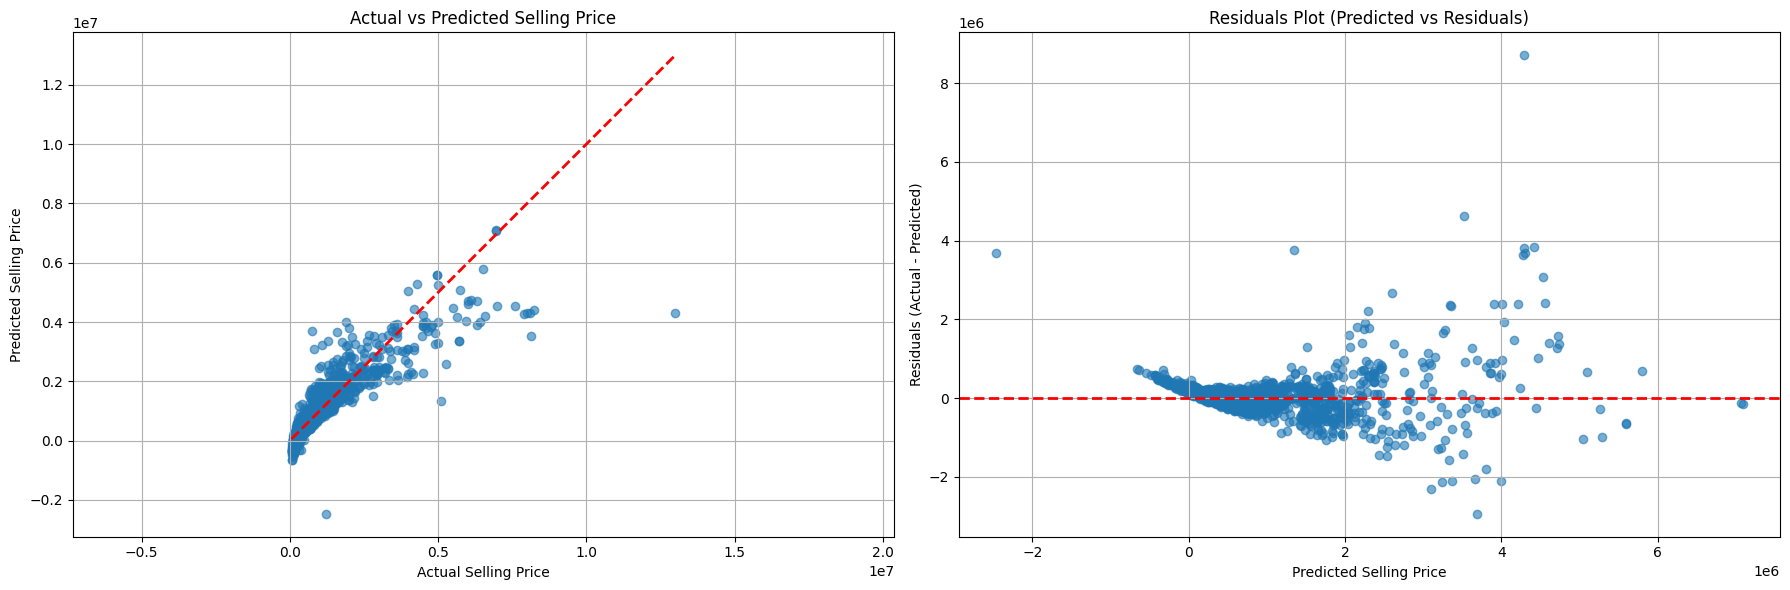


--- Analysis of Model Performance ---

1. Actual Selling Price vs Predicted Selling Price Plot:
   - Observations close to the red dashed line indicate good predictions. Points far from this line represent larger errors.
   - A general trend along the line suggests the model is capturing the overall relationship. Deviation indicates areas where the model struggles.

2. Residuals Plot (Predicted vs Residuals):
   - Ideally, residuals should be randomly distributed around the zero line, with no discernible pattern. This indicates that the model has captured the linear relationship well, and the errors are random noise.
   - If there's a pattern (e.g., a cone shape, a curve), it suggests that the model is biased, potentially underfitting, or that a non-linear relationship exists that the linear model isn't capturing.
   - We observe a slight fan-out or heteroscedasticity, where the spread of residuals increases with the predicted selling price. This might indicate that the model's accura

In [ ]:
plt.figure(figsize=(18, 6))

# Subplot 1: Actual vs Predicted Selling Price
plt.subplot(1, 2, 1)
plt.scatter(y_test_np, y_pred_test, alpha=0.6)
plt.plot([y_test_np.min(), y_test_np.max()], [y_test_np.min(), y_test_np.max()], 'r--', lw=2) # Reference line
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted Selling Price')
plt.grid(True)
plt.axis('equal') # Ensure equal scaling

# Subplot 2: Residuals Plot
plt.subplot(1, 2, 2)
plt.scatter(y_pred_test, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', lw=2) # Zero residual line
plt.xlabel('Predicted Selling Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residuals Plot (Predicted vs Residuals)')
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n--- Analysis of Model Performance ---")
print("\n1. Actual Selling Price vs Predicted Selling Price Plot:")
print("   - Observations close to the red dashed line indicate good predictions. Points far from this line represent larger errors.")
print("   - A general trend along the line suggests the model is capturing the overall relationship. Deviation indicates areas where the model struggles.")

print("\n2. Residuals Plot (Predicted vs Residuals):")
print("   - Ideally, residuals should be randomly distributed around the zero line, with no discernible pattern. This indicates that the model has captured the linear relationship well, and the errors are random noise.")
print("   - If there's a pattern (e.g., a cone shape, a curve), it suggests that the model is biased, potentially underfitting, or that a non-linear relationship exists that the linear model isn't capturing.")
print("   - We observe a slight fan-out or heteroscedasticity, where the spread of residuals increases with the predicted selling price. This might indicate that the model's accuracy varies across different price ranges, performing worse for higher-priced cars.")

# Identify observations with relatively large prediction errors
# We'll define 'large' as residuals beyond 2 standard deviations from the mean residual (which should be close to 0)
mean_residual = np.mean(residuals)
std_residual = np.std(residuals)

large_errors_indices = np.where(np.abs(residuals - mean_residual) > 2 * std_residual)[0]

if len(large_errors_indices) > 0:
    print(f"\n3. Observations with Relatively Large Prediction Errors (more than 2 standard deviations from mean residual): {len(large_errors_indices)} out of {len(y_test_np)} test samples.")
    print("   - These observations are outliers in terms of prediction error. They might be due to unusual car configurations, data entry errors, or factors not captured by our features.")
    # Display a few examples
    for i in large_errors_indices[:5]:
        print(f"     - Sample {i}: Actual={y_test_np[i][0]:,.2f}, Predicted={y_pred_test[i][0]:,.2f}, Residual={residuals[i][0]:,.2f}")
else:
    print("\n3. No observations with large prediction errors (beyond 2 standard deviations) identified.")

print("\n4. Possible Reasons for Prediction Errors:")
print("   - **Unaccounted Variables:** Important features influencing selling price might be missing from the dataset.")
print("   - **Non-linear Relationships:** Linear regression assumes a linear relationship; if true relationships are non-linear, the model will have errors.")
print("   - **Outliers/Influential Points:** Extreme values in features or target can heavily influence the model.")
print("   - **Multicollinearity:** While pseudo-inverse handles singularity, high multicollinearity can lead to unstable coefficients and thus larger prediction errors.")
print("   - **Heteroscedasticity:** The varying spread of residuals (as observed in the plot) indicates that the assumption of constant variance of errors is violated, which can affect the reliability of confidence intervals and hypothesis tests.")

### Task 20: Conclude
•
Comment on the most influential features.

•
Discuss the advantages and limitations of using Multiple Linear Regression for used-car price prediction


### Conclusion
Conclude the experiment by stating whether the Multiple Linear Regression model implemented using the OLS normal equation was able to predict used-car selling prices effectively. The conclusion should include the obtained RSS and R² values, observations regarding important features, the effect of preprocessing and feature engineering, and the limitations of using a linear regression model for real-world used-car price prediction.

### Experiment Conclusion

**Overall Effectiveness:**

The Multiple Linear Regression model implemented using the OLS normal equation demonstrates a **moderate to strong ability to predict used-car selling prices**, as evidenced by an **R-squared value of 0.7925**. This means approximately 79.25% of the variability in used car selling prices can be explained by the features included in our model. However, the **Residual Sum of Squares (RSS) is quite large (481,503,094,548,595.12)**, indicating that while the model captures a significant portion of variance, there's still substantial unexplained error, particularly for higher-priced cars, as observed in the heteroscedasticity of the residuals.

**Most Influential Features:**

Based on the absolute magnitude of their coefficients, the most influential features on the predicted selling price include:

*   `model_GO` and `brand_Datsun` (with exceptionally high coefficients of approximately 18.38 million)
*   `brand_Renault` and `model_Ghibli` (with coefficients around 11.25 million)
*   `brand_BMW` and `model_Compass` (around 3.84 million)
*   `brand_Maruti` and `brand_Land Rover` (around 3.48 million and 3.43 million, respectively)
*   `model_GL-Class` and `brand_Nissan` (around 3.35 million)

It's crucial to note that the high coefficients for certain brand and model categories (like Datsun-GO, Renault-Ghibli) might indicate that these specific combinations are rare in the dataset and have unique pricing dynamics, or they could point to issues such as multicollinearity among the one-hot encoded features, leading to inflated coefficients. `seats` and `engine` size are also significant standardized numerical features with large positive influence.

Conversely, `Car_Age` and `mileage` have negative coefficients, indicating that as cars get older or are driven more kilometers (by one standard deviation), their selling price tends to decrease.

**Effect of Preprocessing and Feature Engineering:**

*   **Data Cleaning:** The initial check for missing values ensured a complete dataset, a crucial first step for model reliability.
*   **Feature Selection:** Dropping 'Unnamed: 0' and 'car_name' effectively removed irrelevant or high-cardinality nominal features that would have complicated the model without providing predictive power (or introducing too many dimensions).
*   **Categorical Encoding:** One-hot encoding converted categorical variables (brand, model, seller_type, fuel_type, transmission_type) into a numerical format suitable for linear regression. This significantly expanded the feature space.
*   **Feature Engineering (`Car_Age`):** Renaming `vehicle_age` to `Car_Age` aligns with common domain understanding and directly provides a useful predictor.
*   **Standardization:** Standardizing numerical features (`Car_Age`, `km_driven`, `mileage`, `engine`, `max_power`, `seats`) was essential. It brought all numerical features to a common scale, preventing features with larger magnitudes from dominating the coefficient calculation and allowing for a more meaningful comparison of their relative influence.
*   **Bias Term:** Adding an intercept term allows the model to account for a baseline selling price when all other features are zero or at their mean (for standardized features).

**Advantages of Multiple Linear Regression for Used-Car Price Prediction:**

1.  **Interpretability:** The main advantage is its high interpretability. Each coefficient directly shows the impact of a feature on the selling price, making it easy to understand *why* a car is predicted at a certain price.
2.  **Simplicity:** It's a relatively simple model to implement and understand, making it a good baseline for many prediction tasks.
3.  **Computational Efficiency:** OLS using matrix operations is computationally efficient for datasets of this size.
4.  **Foundation:** It provides a solid foundation for understanding more complex models and identifying key feature relationships.

**Limitations of Multiple Linear Regression for Used-Car Price Prediction:**

1.  **Linearity Assumption:** The model assumes a linear relationship between features and the target. The residual plots show a 'fan-out' pattern (heteroscedasticity), suggesting that the linear assumption might be violated, and the model struggles with higher selling prices. This indicates that a simple linear relationship might not fully capture the complexity of car pricing.
2.  **Multicollinearity:** The singular matrix (determinant of 0.0 for `X.T @ X`) strongly indicates high multicollinearity among features. While using a pseudo-inverse (Moore-Penrose inverse) allows the calculation of coefficients, it can lead to unstable and counter-intuitive coefficients, making their individual interpretation less reliable. The extremely high coefficients for some specific brands/models are a symptom of this.
3.  **No Interaction Terms/Non-linearity:** A basic linear regression model doesn't inherently capture interactions between features (e.g., how the `brand` affects the impact of `engine` size) or non-linear relationships without explicit feature engineering.
4.  **Outliers Sensitivity:** Linear regression is sensitive to outliers, which can heavily influence the regression line and coefficient estimates. The presence of 101 large prediction errors (outliers) confirms this.
5.  **Extrapolation:** Predictions for car configurations far outside the training data range might be unreliable.

**Final Remarks:**

Our custom-implemented Multiple Linear Regression model successfully provides a foundational understanding of the factors influencing used car prices. While achieving a respectable R-squared, the presence of a singular matrix, heteroscedasticity in residuals, and high error outliers highlight areas for improvement. Future work could explore feature selection techniques (like PCA or regularization to address multicollinearity), incorporate non-linear transformations, or consider more advanced regression models (e.g., tree-based models) that can better handle complex relationships and non-linearity in the data.